# This notebook was used to characterize halo size

Required libraries: Plots and LaTeXStrings

Run the notebook top to bottom

# Libraries, Functions & Parameters

Libraries

In [ ]:
using Plots
using LaTeXStrings

Functions

In [ ]:
function laplacian(n)
  N = size(n, 1)
  lap = similar(n)

  for j in 1:N, i in 1:N
    ip = mod1(i+1, N)
    im = mod1(i-1, N)
    jp = mod1(j+1, N)
    jm = mod1(j-1, N)
    lap[i,j] = n[ip,j] + n[im,j] + n[i,jp] + n[i,jm] - 4*n[i,j]
  end

  return lap
end

function step(n,dt,omega,a,b,eps)
  lap = laplacian(n)
  dndt = omega.*n + a.*n.^2 - b.*n.^3 + eps*lap

  return n + dt*dndt
end

function grazing(positions, N, α, σ)
  F = zeros(N, N)
  limit = σ*3 # 99.7% of the gaussian distribution

  for (cx, cy) in positions
    for i in cx-limit:cx+limit, j in cy-limit:cy+limit
      ii = mod1(i, N)
      jj = mod1(j, N)
      r2 = (i - cx)^2 + (j - cy)^2
      F[ii, jj] += exp(-r2 / (2*σ^2))
    end
  end

  return (α / (2π * σ^2)) * F
end

function stepcrabs(n, dt, omega, a, b, eps, crab_positions, α, σ, ρa)
  lap   = laplacian(n)
  graze = grazing(crab_positions, size(n,1), α, σ)
  dndt = omega.*n + a.*n.^2 - b.*n.^3 + eps*lap - graze./ρa

  return max.(0.0, n + dt*dndt)
end

step (generic function with 1 method)

Project parameters

In [ ]:
# Lattice
L = 200 #cm
ΔL = 1 #cm
N = Int(L/ΔL) #lattice units
dt = 0.1 # day

# Wet to Dry convertion
WW_to_DW = 0.1

# Crabs
σ = 30
α = 3.83*WW_to_DW #[gr DW crab⁻¹ day⁻¹]

# Algae (Computed in "Algae parameter ajustment")
ρa = 0.01 #[gr DW cm⁻²]
scale = 0.055
omega = -0.4 * scale
a = 1.4 * scale
b = 1.0 * scale
eps = 0.9

0.9

# Halo formation

## Changing $\sigma$

For σ = 10 cm, Halo = 26 cm


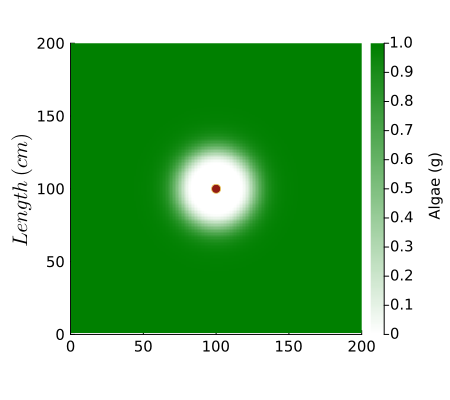

For σ = 20 cm, Halo = 37 cm


[ Info: Saved animation to /content/Halo σ=10.gif


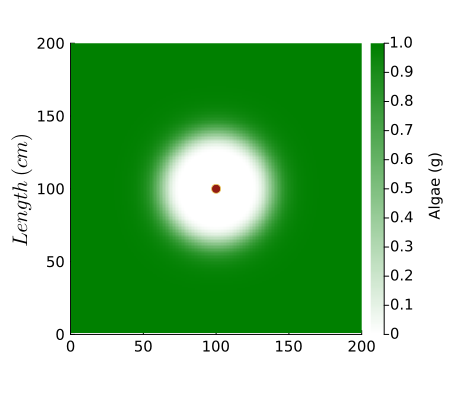

For σ = 30 cm, Halo = 33 cm


[ Info: Saved animation to /content/Halo σ=20.gif


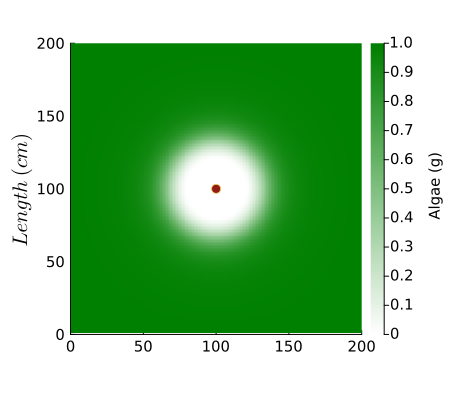

For σ = 40 cm, Halo = 0 cm


[ Info: Saved animation to /content/Halo σ=30.gif


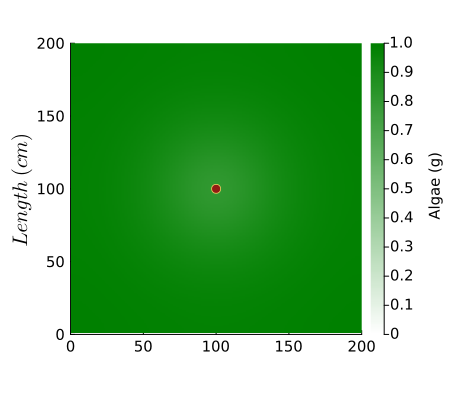

For σ = 50 cm, Halo = 0 cm


[ Info: Saved animation to /content/Halo σ=40.gif


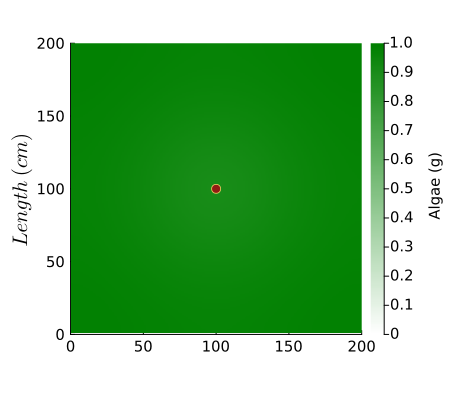

[ Info: Saved animation to /content/Halo σ=50.gif


In [ ]:
σ_sweep = 10:10:50
simulation_time = Int(3650) #1 year

# Crab placements
n_crabs = 1
crab_positions = [(N÷2,N÷2)]

for σ in σ_sweep
  anim = Animation()
  n = ones(N,N) * 0.7 + rand(N,N) * 0.2 #80% algae capacity
  p = plot()
  halo = 0

  for i in 1:simulation_time
    n = stepcrabs(n, dt, omega, a, b, eps, crab_positions, α, σ, ρa)

    if i % 20 == 0
      p = heatmap(n,
        aspect_ratio=:equal,
        grid=false,
        color=cgrad([:white, :green]),
        clims=(0.0, 1),
        xlims=(0,N),
        ylims=(0,N),
        ylabel = L"Length\ (cm)",
        colorbar_title = "\n Algae (g)",
        guidefontsize = 14,
        tickfontsize  = 10,
        right_margin = 5mm,
        size=(450,400)
      )

      scatter!(last.(crab_positions), first.(crab_positions),
        markersize = 5,
        color="#921b13",
        markerstrokecolor="#efd063",
        #label="crab",
        label=false
      )

      #plot!(legend=:outerbottom)

      frame(anim, p)
    end
  end

  # Halo size
  for l in N÷2:N
    if n[N÷2,l] > 0.4
      halo = l-N÷2
      println("For σ = $σ cm, Halo = $halo cm")
      break
    end
  end

  savefig(p, "Halo σ=$σ.png")
  display(p)
  gif(anim, "Halo σ=$σ.gif", fps=10)
end

Size vs σ

In [ ]:
σ_sweep = 0:40 #cm
simulation_time = Int(3650) #1 year

# Crab placements
n_crabs = 1
crab_positions = [(N÷2,N÷2)]

halo = zeros(length(σ_sweep))

for σ in σ_sweep
  n = ones(N,N) * 0.7 + rand(N,N) * 0.2 #80% algae capacity

  for i in 1:simulation_time
    n = stepcrabs(n, dt, omega, a, b, eps, crab_positions, α, σ, ρa)
  end

  # Halo size
  for l in N÷2:N
    if n[N÷2,l] > 0.4
      halo[σ] = l-N÷2 #cm
      break
    end
  end
end

# Range of biggest values
max_h = maximum(values(halo))
biggest_halo_sigmas = [σ for (σ, h) in pairs(halo) if h == max_h]

println("Maximum halo size = $max_h")
println(biggest_halo_sigmas)

# Graph
p = plot(σ_sweep,halo,
  xlabel = L"Grazing\ distance\ σ\ (cm)",
  ylabel = L"Halo\ size\ (cm)",
  ylims = (0, 40),
  xlims = (0, 40),
  color = :black,
  legend = false,
  grid = false,
  guidefontsize = 14,
  tickfontsize  = 10,
  size = (400,400),
  dpi = 300
)
savefig(p, "Halo size vs σ.png")

Maximum halo size = 38.0
[21, 22, 23, 24, 25, 26]


"/content/Halo size vs σ.png"

## Changing the consumption $\alpha$

For α = 0.41, Halo = 0 cm


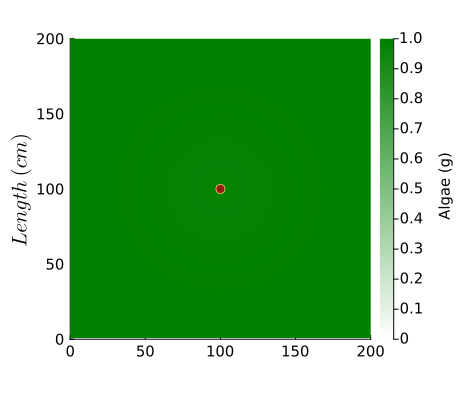

[ Info: Saved animation to /content/Halo α=0.41.gif


For α = 2.12, Halo = 0 cm


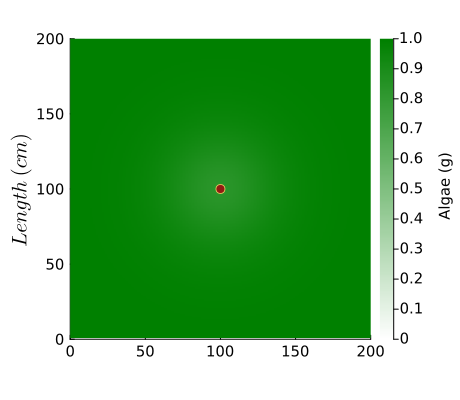

For α = 3.83, Halo = 33 cm


[ Info: Saved animation to /content/Halo α=2.12.gif


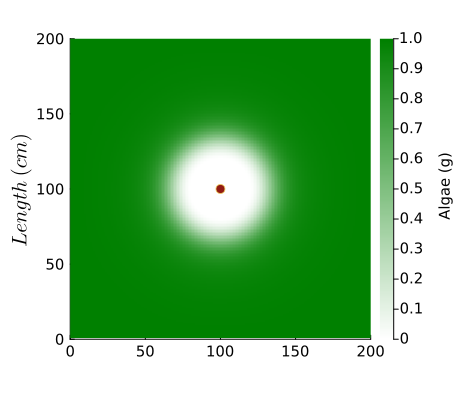

For α = 5.54, Halo = 46 cm


[ Info: Saved animation to /content/Halo α=3.83.gif


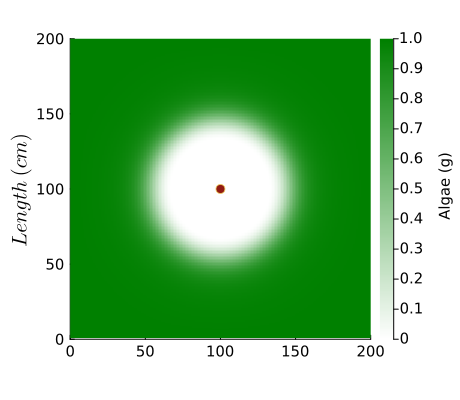

For α = 7.25, Halo = 52 cm


[ Info: Saved animation to /content/Halo α=5.54.gif


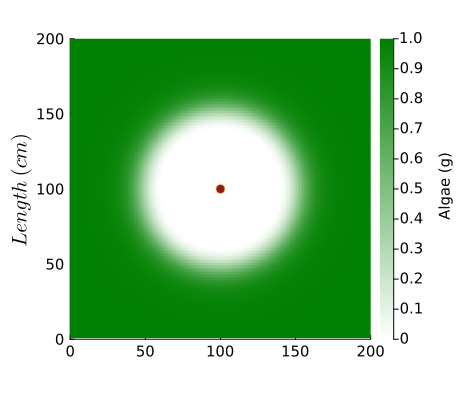

[ Info: Saved animation to /content/Halo α=7.25.gif


In [ ]:
α_sweep = [0.41, 2.12, 3.83, 5.54, 7.25]
simulation_time = Int(3650) #1 year

# Crab placements
n_crabs = 1
crab_positions = [(N÷2,N÷2)]

for al in α_sweep
  anim = Animation()
  n = ones(N,N) * 0.7 + rand(N,N) * 0.2 #80% algae capacity
  p = plot()
  α = al * WW_to_DW
  halo = 0

  for i in 1:simulation_time
    n = stepcrabs(n, dt, omega, a, b, eps, crab_positions, α, σ, ρa)

    if i % 20 == 0
      p = heatmap(n,
        aspect_ratio=:equal,
        grid=false,
        color=cgrad([:white, :green]),
        clims=(0.0, 1),
        xlims=(0,N),
        ylims=(0,N),
        ylabel = L"Length\ (cm)",
        colorbar_title = "\n Algae (g)",
        guidefontsize = 14,
        tickfontsize  = 10,
        right_margin = 5mm,
        size=(460,400)
      )

      scatter!(last.(crab_positions), first.(crab_positions),
        markersize = 5,
        color="#921b13",
        markerstrokecolor="#efd063",
        #label="crab",
        label=false
      )

      #plot!(legend=:outerbottom)

      frame(anim, p)
    end
  end

  # Halo size
  for l in N÷2:N
    if n[N÷2,l] > 0.4
      halo = l-N÷2
      println("For α = $al, Halo = $halo cm")
      break
    end
  end

  savefig(p, "Halo α=$al.png")
  display(p)
  gif(anim, "Halo α=$al.gif", fps=10)
end

Size vs α

In [ ]:
α_sweep = 0:1:20 #g WW day^{-1}
simulation_time = Int(3650) #1 year

# Crab placements
n_crabs = 1
crab_positions = [(N÷2,N÷2)]

halo = zeros(length(α_sweep))

for (x, al) in enumerate(α_sweep)
  n = ones(N,N) * 0.7 + rand(N,N) * 0.2 #80% algae capacity
  α = al * WW_to_DW

  for i in 1:simulation_time
    n = stepcrabs(n, dt, omega, a, b, eps, crab_positions, α, σ, ρa)
  end

  # Halo size
  for l in N÷2:N
    if n[N÷2,l] > 0.4
      halo[x] = l-N÷2 #cm
      break
    end
  end
end

# Graph
p = plot(α_sweep,halo,
  xlabel = L"Algae\ consumption\ \alpha\ (g\ WW\ day^{-1})",
  ylabel = L"Halo\ size\ (cm)",
  ylims = (0, 80),
  xlims = (0, 20),
  color = :black,
  legend = false,
  grid = false,
  guidefontsize = 14,
  tickfontsize  = 10,
  size = (400,400),
  dpi = 300
)
savefig(p, "Halo size vs α.png")

"/content/Halo size vs α.png"